#Importação de bibliotecas e do dataset

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive
mount_path = '/content/drive/'
drive.mount(mount_path)

file_path = mount_path + 'My Drive/Colab Notebooks/salario_profissionais_dados.csv'

plt.style.use('default')
sns.set()

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


#Carregamento de dados


In [6]:

df = pd.read_csv(file_path)

df.head()

,work_year,country,region,experience_level,job_title,salary_in_usd,employee_residence,company_location,company_size,years_of_experience
0,2023,Spain,Europe,SE,Principal Data Scientist,85847.0,ES,ES,L,8.0
1,2023,United States of America,Americas,MI,ML Engineer,30000.0,US,US,S,5.0
2,2023,United States of America,Americas,MI,ML Engineer,25500.0,US,US,S,3.0
3,2023,Canada,Americas,SE,Data Scientist,175000.0,CA,CA,M,8.0
4,2023,Canada,Americas,SE,Data Scientist,120000.0,CA,CA,M,8.0


#Exploração inicial dos dados

In [10]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3755 entries, 0 to 3754
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   work_year            3755 non-null   object 
 1   country              3735 non-null   object 
 2   region               3735 non-null   object 
 3   experience_level     3735 non-null   object 
 4   job_title            3735 non-null   object 
 5   salary_in_usd        3735 non-null   float64
 6   employee_residence   3735 non-null   object 
 7   company_location     3735 non-null   object 
 8   company_size         3735 non-null   object 
 9   years_of_experience  3735 non-null   float64
dtypes: float64(2), object(8)
memory usage: 293.5+ KB


,0
work_year,0
country,20
region,20
experience_level,20
job_title,20
salary_in_usd,20
employee_residence,20
company_location,20
company_size,20
years_of_experience,20


A base possui 20 registros e 10 colunas, com alguns valores nulos em determinadas variáveis.

#Limpeza de dados

Existem muitos nulos no dataset. Algumas perguntas deverão ser respondidas antes da limpeza dos dados:

Erro de coleta?
Campo opcional?
Dado não aplicável?



In [22]:
df.isnull()

,work_year,country,region,experience_level,job_title,salary_in_usd,employee_residence,company_location,company_size,years_of_experience
0,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...
3750,False,False,False,False,False,False,False,False,False,False
3751,False,False,False,False,False,False,False,False,False,False
3752,False,False,False,False,False,False,False,False,False,False
3753,False,False,False,False,False,False,False,False,False,False


In [21]:
(df.isnull().mean() * 100).round(2)


,0
work_year,0.00
country,0.53
region,0.53
experience_level,0.53
job_title,0.53
salary_in_usd,0.53
employee_residence,0.53
company_location,0.53
company_size,0.53
years_of_experience,0.53


In [23]:
df[df.isnull().any(axis=1)].head()

,work_year,country,region,experience_level,job_title,salary_in_usd,employee_residence,company_location,company_size,years_of_experience
84,"2023,""Netherlands, Kingdom of the"",Europe,MI,M...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
471,"2022,""Netherlands, Kingdom of the"",Europe,EN,D...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1321,"2023,""Netherlands, Kingdom of the"",Europe,SE,C...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1340,"2023,""Netherlands, Kingdom of the"",Europe,SE,A...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1757,"2022,""Netherlands, Kingdom of the"",Europe,SE,D...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Verificado que apenas uma coluna possui linhas preenchidas, enquanto 9 de 10 colunas apresentam igualmente 20 linhas com informações nulas em cada coluna. Podemos constatar que as informações das demais colunas, constam todas na coluna work_year. O dataset foi mal estruturado (dados “deslocados”)

In [46]:
df = pd.read_csv(file_path, sep=',')

df.head()

,work_year,country,region,experience_level,job_title,salary_in_usd,employee_residence,company_location,company_size,years_of_experience
0,2023,Spain,Europe,SE,Principal Data Scientist,85847.0,ES,ES,L,8.0
1,2023,United States of America,Americas,MI,ML Engineer,30000.0,US,US,S,5.0
2,2023,United States of America,Americas,MI,ML Engineer,25500.0,US,US,S,3.0
3,2023,Canada,Americas,SE,Data Scientist,175000.0,CA,CA,M,8.0
4,2023,Canada,Americas,SE,Data Scientist,120000.0,CA,CA,M,8.0


In [48]:
df['job_title'] = df['job_title'].str.strip()
df.head()

,work_year,country,region,experience_level,job_title,salary_in_usd,employee_residence,company_location,company_size,years_of_experience
0,2023,Spain,Europe,SE,Principal Data Scientist,85847.0,ES,ES,L,8.0
1,2023,United States of America,Americas,MI,ML Engineer,30000.0,US,US,S,5.0
2,2023,United States of America,Americas,MI,ML Engineer,25500.0,US,US,S,3.0
3,2023,Canada,Americas,SE,Data Scientist,175000.0,CA,CA,M,8.0
4,2023,Canada,Americas,SE,Data Scientist,120000.0,CA,CA,M,8.0


#Análise por experiência

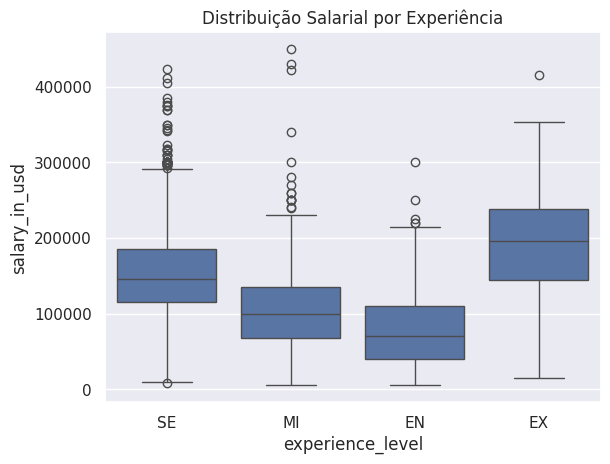

In [49]:
plt.figure()
sns.boxplot(x='experience_level', y='salary_in_usd', data=df)
plt.title('Distribuição Salarial por Experiência')
plt.show()

Profissionais seniores apresentam maior dispersão salarial, indicando maior variação de remuneração.

#Top cargos mais bem pagos

Text(0, 0.5, 'Cargo')

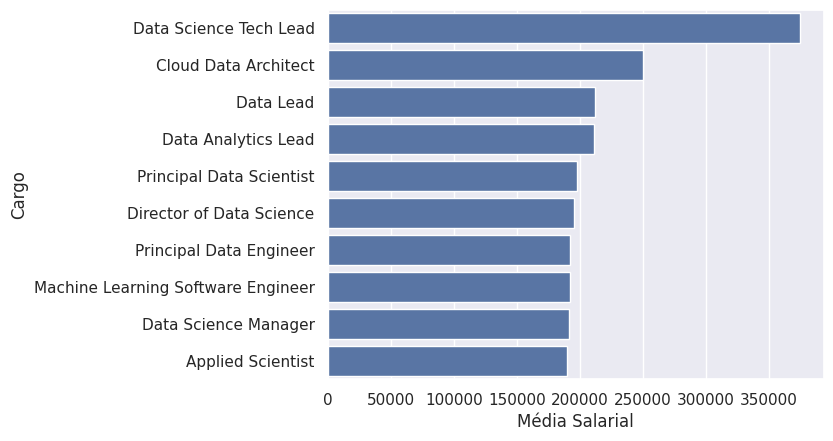

In [62]:
top_jobs = df.groupby('job_title')['salary_in_usd'].mean().sort_values(ascending=False).head(10)
plt.figure

sns.barplot(x=top_jobs.values, y=top_jobs.index)
plt.xlabel('Média Salarial')
plt.ylabel('Cargo')



Cargos mais especializados tendem a apresentar maior remuneração média.

#Salário por tamanho da empresa


<Axes: xlabel='company_size', ylabel='salary_in_usd'>

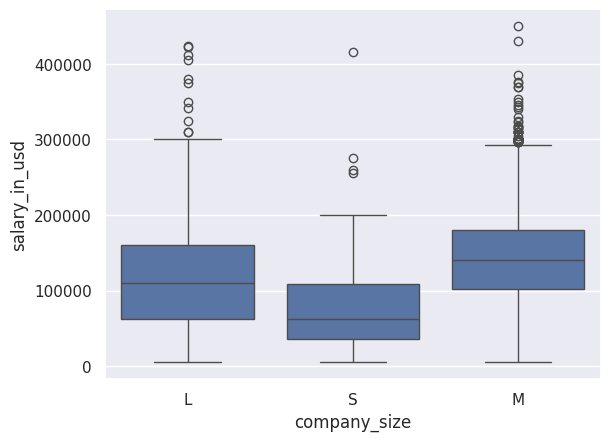

In [61]:
sns.boxplot(x='company_size', y='salary_in_usd', data=df)

#Salário por país

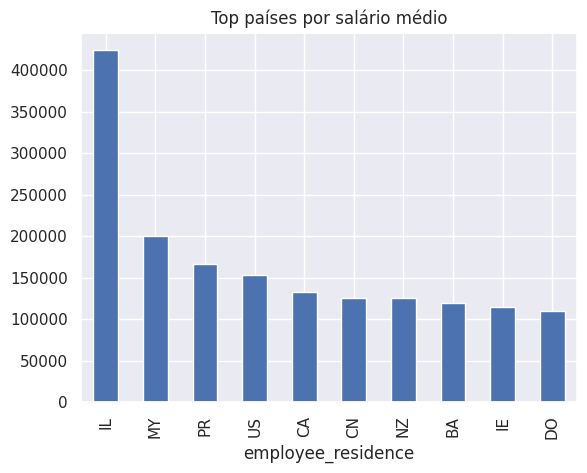

In [63]:
country_salary = df.groupby('employee_residence')['salary_in_usd'].mean().sort_values(ascending=False).head(10)

plt.figure()
country_salary.plot(kind='bar')
plt.title('Top países por salário médio')
plt.show()


#Correlação

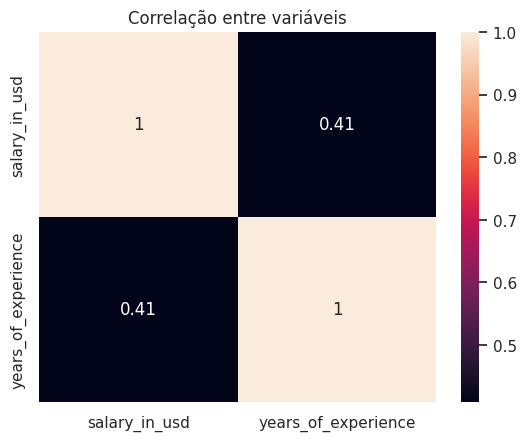

In [64]:
corr = df.corr(numeric_only=True)

plt.figure()
sns.heatmap(corr, annot=True)
plt.title('Correlação entre variáveis')
plt.show()

#Conclusão


A experiência é um dos principais fatores de impacto no salário
. Localização geográfica influencia fortemente a remuneração
Cargos especializados possuem maior valorização.
O trabalho remoto apresenta competitividade global